(sympy)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`SymPy <single: SymPy>`

```{index} single: Python; SymPy
```

## مروری کلی

برخلاف کتابخانه‌های عددی که با مقادیر سروکار دارند، [SymPy](https://www.sympy.org/en/index.html) بر دستکاری مستقیم نمادها و عبارات ریاضی تمرکز دارد.

SymPy [طیف گسترده‌ای از قابلیت‌ها](https://www.sympy.org/en/features.html) را فراهم می‌کند از جمله

- عبارات نمادین
- حل معادلات
- ساده‌سازی
- حساب دیفرانسیل و انتگرال
- ماتریس‌ها
- ریاضیات گسسته و غیره

این توابع SymPy را به یک جایگزین متن‌باز محبوب برای سایر نرم‌افزارهای محاسباتی نمادین اختصاصی مانند Mathematica تبدیل می‌کند.

در این سخنرانی، برخی از قابلیت‌های SymPy را بررسی خواهیم کرد و نحوه استفاده از توابع اولیه SymPy برای حل مدل‌های اقتصادی را نشان خواهیم داد.

## شروع به کار

ابتدا کتابخانه را وارد کرده و چاپگر را برای خروجی نمادین مقداردهی اولیه می‌کنیم

In [1]:
from sympy import *
from sympy.plotting import plot, plot3d_parametric_line, plot3d
from sympy.solvers.inequalities import reduce_rational_inequalities
from sympy.stats import Poisson, Exponential, Binomial, density, moment, E, cdf

import numpy as np
import matplotlib.pyplot as plt

# Enable the mathjax printer
init_printing(use_latex='mathjax')

## جبر نمادین

### نمادها

ابتدا چند نماد را برای کار با آن‌ها مقداردهی اولیه می‌کنیم

In [2]:
x, y, z = symbols('x y z')

نمادها واحدهای اساسی برای محاسبات نمادین در SymPy هستند.

### عبارات

اکنون می‌توانیم از نمادهای `x`، `y` و `z` برای ساختن عبارات و معادلات استفاده کنیم.

در اینجا ابتدا یک عبارت ساده می‌سازیم

In [3]:
expr = (x+y) ** 2
expr

       2
(x + y) 

می‌توانیم این عبارت را با تابع `expand` بسط دهیم

In [4]:
expand_expr = expand(expr)
expand_expr

 2            2
x  + 2⋅x⋅y + y 

و آن را با تابع `factor` به فرم فاکتورگیری شده برگردانیم

In [5]:
factor(expand_expr)

       2
(x + y) 

می‌توانیم این عبارت را حل کنیم

In [6]:
solve(expr)

[{x: -y}]

توجه کنید این معادل حل معادله زیر برای `x` است

$$
(x + y)^2 = 0 
$$

```{note}
[Solvers](https://docs.sympy.org/latest/modules/solvers/index.html) یک ماژول مهم با ابزارهایی برای حل انواع مختلف معادلات است.

انواع مختلفی از حل‌کننده‌ها در SymPy بسته به ماهیت مسئله در دسترس هستند.
```

### معادلات

SymPy چندین تابع برای دستکاری معادلات فراهم می‌کند.

بیایید یک معادله با عبارتی که قبلاً تعریف کردیم توسعه دهیم

In [7]:
eq = Eq(expr, 0)
eq

       2    
(x + y)  = 0

حل این معادله نسبت به $x$ همان خروجی حل مستقیم عبارت را می‌دهد

In [8]:
solve(eq, x)

[-y]

SymPy می‌تواند معادلات با چندین جواب را مدیریت کند

In [9]:
eq = Eq(expr, 1)
solve(eq, x)

[1 - y, -y - 1]

تابع `solve` همچنین می‌تواند چندین معادله را با هم ترکیب کرده و یک دستگاه معادلات را حل کند

In [10]:
eq2 = Eq(x, y)
eq2

x = y

In [11]:
solve([eq, eq2], [x, y])

[(-1/2, -1/2), (1/2, 1/2)]

همچنین می‌توانیم مقدار $y$ را با جایگزینی ساده $x$ با $y$ حل کنیم

In [12]:
expr_sub = expr.subs(x, y)
expr_sub

   2
4⋅y 

In [13]:
solve(Eq(expr_sub, 1))

[-1/2, 1/2]

در زیر نمونه معادله دیگری با نماد `x` و توابع `sin`، `cos` و `tan` با استفاده از تابع `Eq` آورده شده است

In [14]:
# Create an equation
eq = Eq(cos(x) / (tan(x)/sin(x)), 0)
eq

sin(x)⋅cos(x)    
───────────── = 0
   tan(x)        

اکنون این معادله را با استفاده از تابع `simplify` ساده می‌کنیم

In [15]:
# Simplify an expression
simplified_expr = simplify(eq)
simplified_expr

   2       
cos (x) = 0

دوباره از تابع `solve` برای حل این معادله استفاده می‌کنیم

In [16]:
# Solve the equation
sol = solve(eq, x)
sol

⎡-π   π⎤
⎢───, ─⎥
⎣ 2   2⎦

SymPy همچنین می‌تواند معادلات پیچیده‌تری شامل مثلثات و اعداد مختلط را مدیریت کند.

این را با استفاده از [فرمول اویلر](https://en.wikipedia.org/wiki/Euler%27s_formula) نشان می‌دهیم

In [17]:
# 'I' represents the imaginary number i 
euler = cos(x) + I*sin(x)
euler

ⅈ⋅sin(x) + cos(x)

In [18]:
simplify(euler)

 ⅈ⋅x
ℯ   

اگر علاقه‌مند هستید، شما را تشویق می‌کنیم سخنرانی در مورد [مثلثات و اعداد مختلط](https://python.quantecon.org/complex_and_trig.html) را مطالعه کنید.

#### مثال: محاسبه نقطه ثابت

محاسبه نقطه ثابت به طور مکرر در اقتصاد و مالی استفاده می‌شود.

در اینجا نقطه ثابت دینامیک رشد سولو-سوان را حل می‌کنیم:

$$
k_{t+1}=s f\left(k_t\right)+(1-\delta) k_t, \quad t=0,1, \ldots
$$

که در آن $k_t$ ذخیره سرمایه است، $f$ یک تابع تولید است، $\delta$ نرخ استهلاک است.

ما به محاسبه نقطه ثابت این دینامیک علاقه‌مندیم، یعنی مقدار $k$ به طوری که $k_{t+1} = k_t$.

با $f(k) = Ak^\alpha$، می‌توانیم نقطه ثابت منحصر به فرد دینامیک $k^*$ را با استفاده از قلم و کاغذ نشان دهیم:

$$
k^*:=\left(\frac{s A}{\delta}\right)^{1 /(1-\alpha)}
$$ 

این می‌تواند به راحتی در SymPy محاسبه شود

In [19]:
A, s, k, α, δ = symbols('A s k^* α δ')

اکنون برای نقطه ثابت $k^*$ حل می‌کنیم

$$
k^* = sA(k^*)^{\alpha}+(1-\delta) k^*
$$

In [20]:
# Define Solow-Swan growth dynamics
solow = Eq(s*A*k**α + (1-δ)*k, k)
solow

      α                        
A⋅k__* ⋅s + k__*⋅(1 - δ) = k__*

In [21]:
solve(solow, k)

⎡      -1  ⎤
⎢     ─────⎥
⎢     α - 1⎥
⎢⎛A⋅s⎞     ⎥
⎢⎜───⎟     ⎥
⎣⎝ δ ⎠     ⎦

### نامساوی‌ها و منطق

SymPy همچنین به کاربران اجازه می‌دهد نامساوی‌ها و عملگرهای مجموعه را تعریف کنند و طیف گسترده‌ای از [عملیات](https://docs.sympy.org/latest/modules/solvers/inequalities.html) را فراهم می‌کند.

In [22]:
reduce_inequalities([2*x + 5*y <= 30, 4*x + 2*y <= 20], [x])

        y            5⋅y         
x ≤ 5 - ─ ∧ x ≤ 15 - ─── ∧ -∞ < x
        2             2          

In [23]:
And(2*x + 5*y <= 30, x > 0)

2⋅x + 5⋅y ≤ 30 ∧ x > 0

### سری‌ها

سری‌ها به طور گسترده در اقتصاد و آمار، از قیمت‌گذاری دارایی تا انتظار متغیرهای تصادفی گسسته، استفاده می‌شوند.

می‌توانیم یک سری ساده از جمع‌ها را با استفاده از تابع `Sum` و نمادهای `Indexed` بسازیم

In [24]:
x, y, i, j = symbols("x y i j")
sum_xy = Sum(Indexed('x', i)*Indexed('y', j), 
            (i, 0, 3),
            (j, 0, 3))
sum_xy

  3     3            
 ___   ___           
 ╲     ╲             
  ╲     ╲            
  ╱     ╱   x[i]⋅y[j]
 ╱     ╱             
 ‾‾‾   ‾‾‾           
j = 0 i = 0          

برای محاسبه مجموع، می‌توانیم فرمول را [`lambdify`](https://docs.sympy.org/latest/modules/utilities/lambdify.html#sympy.utilities.lambdify.lambdify) کنیم.

عبارت lambdify شده می‌تواند مقادیر عددی را به عنوان ورودی برای $x$ و $y$ دریافت کرده و نتیجه را محاسبه کند

In [25]:
sum_xy = lambdify([x, y], sum_xy)
grid = np.arange(0, 4, 1)
sum_xy(grid, grid)

np.int64(36)

#### مثال: سپرده‌های بانکی

یک بانک با $D_0$ به عنوان سپرده در زمان $t$ را تصور کنید.

این بانک $(1-r)$ از سپرده‌های خود را وام می‌دهد و کسری $r$ را به عنوان ذخایر نقدی نگه می‌دارد.

سپرده‌های آن در یک افق زمانی نامحدود را می‌توان به صورت زیر نوشت

$$
\sum_{i=0}^\infty (1-r)^i D_0
$$

بیایید سپرده‌ها را در زمان $t$ محاسبه کنیم

In [26]:
D = symbols('D_0')
r = Symbol('r', positive=True)
Dt = Sum('(1 - r)^i * D_0', (i, 0, oo))
Dt

  ∞              
 ___             
 ╲               
  ╲             i
  ╱   D₀⋅(1 - r) 
 ╱               
 ‾‾‾             
i = 0            

می‌توانیم متد `doit` را برای محاسبه سری فراخوانی کنیم

In [27]:
Dt.doit()

   ⎛⎧      1                        ⎞
   ⎜⎪      ─         for │r - 1│ < 1⎟
   ⎜⎪      r                        ⎟
   ⎜⎪                               ⎟
   ⎜⎪  ∞                            ⎟
   ⎜⎪ ___                           ⎟
D₀⋅⎜⎨ ╲                             ⎟
   ⎜⎪  ╲          i                 ⎟
   ⎜⎪  ╱   (1 - r)      otherwise   ⎟
   ⎜⎪ ╱                             ⎟
   ⎜⎪ ‾‾‾                           ⎟
   ⎜⎪i = 0                          ⎟
   ⎝⎩                               ⎠

ساده‌سازی عبارت بالا نتیجه زیر را می‌دهد

In [28]:
simplify(Dt.doit())

⎧       D₀                           
⎪       ──          for r > 0 ∧ r < 2
⎪       r                            
⎪                                    
⎪     ∞                              
⎪    ___                             
⎨    ╲                               
⎪     ╲          i                   
⎪D₀⋅  ╱   (1 - r)       otherwise    
⎪    ╱                               
⎪    ‾‾‾                             
⎪   i = 0                            
⎩                                    

این با راه‌حل در سخنرانی در مورد [سری هندسی](https://intro.quantecon.org/geom_series.html#example-the-money-multiplier-in-fractional-reserve-banking) سازگار است.

#### مثال: متغیر تصادفی گسسته

در مثال زیر، انتظار یک متغیر تصادفی گسسته را محاسبه می‌کنیم.

بیایید یک متغیر تصادفی گسسته $X$ با [توزیع پواسون](https://en.wikipedia.org/wiki/Poisson_distribution) تعریف کنیم:

$$
f(x) = \frac{\lambda^x e^{-\lambda}}{x!}, \quad x = 0, 1, 2, \ldots
$$

In [29]:
λ = symbols('lambda')

# We refine the symbol x to positive integers
x = Symbol('x', integer=True, positive=True)
pmf = λ**x * exp(-λ) / factorial(x)
pmf

 x  -λ
λ ⋅ℯ  
──────
  x!  

می‌توانیم بررسی کنیم که آیا مجموع احتمالات برای تمام مقادیر ممکن برابر با $1$ است:

$$
\sum_{x=0}^{\infty} f(x) = 1
$$

In [30]:
sum_pmf = Sum(pmf, (x, 0, oo))
sum_pmf.doit()

1

انتظار توزیع به صورت زیر است:

$$
E(X) = \sum_{x=0}^{\infty} x f(x) 
$$

In [31]:
fx = Sum(x*pmf, (x, 0, oo))
fx.doit()

λ

SymPy شامل یک ماژول فرعی آمار به نام [`Stats`](https://docs.sympy.org/latest/modules/stats.html) است.

`Stats` توزیع‌های داخلی و توابعی روی توزیع‌های احتمال ارائه می‌دهد.

محاسبه بالا همچنین می‌تواند با استفاده از تابع انتظار `E` در ماژول `Stats` به یک خط فشرده شود

In [32]:
λ = Symbol("λ", positive = True)

# Using sympy.stats.Poisson() method
X = Poisson("x", λ)
E(X)

λ

## حساب دیفرانسیل و انتگرال نمادین

SymPy به ما اجازه می‌دهد عملیات مختلف حساب دیفرانسیل و انتگرال مانند حد، مشتق‌گیری و انتگرال‌گیری را انجام دهیم.

### حدها

می‌توانیم حد را برای یک عبارت داده شده با استفاده از تابع `limit` محاسبه کنیم

In [33]:
# Define an expression
f = x**2 / (x-1)

# Compute the limit
lim = limit(f, x, 0)
lim

0

### مشتقات

می‌توانیم هر عبارت SymPy را با استفاده از تابع `diff` مشتق‌گیری کنیم

In [34]:
# Differentiate a function with respect to x
df = diff(f, x)
df

      2           
     x        2⋅x 
- ──────── + ─────
         2   x - 1
  (x - 1)         

### انتگرال‌ها

می‌توانیم انتگرال‌های معین و نامعین را با استفاده از تابع `integrate` محاسبه کنیم

In [35]:
# Calculate the indefinite integral
indef_int = integrate(df, x)
indef_int

      1  
x + ─────
    x - 1

بیایید از این تابع برای محاسبه تابع مولد گشتاور [توزیع نمایی](https://en.wikipedia.org/wiki/Exponential_distribution) با تابع چگالی احتمال استفاده کنیم:

$$
f(x) = \lambda e^{-\lambda x}, \quad x \ge 0
$$

In [36]:
λ = Symbol('lambda', positive=True)
x = Symbol('x', positive=True)
pdf = λ * exp(-λ*x)
pdf

   -λ⋅x
λ⋅ℯ    

In [37]:
t = Symbol('t', positive=True)
moment_t = integrate(exp(t*x) * pdf, (x, 0, oo))
simplify(moment_t)

⎧        λ                       λ    
⎪      ─────         for λ > t ∧ ─ ≠ 1
⎪      λ - t                     t    
⎪                                     
⎪  ∞                                  
⎨  ⌠                                  
⎪  ⎮  x⋅(-λ + t)                      
⎪λ⋅⎮ ℯ           dx      otherwise    
⎪  ⌡                                  
⎪  0                                  
⎩                                     

توجه کنید که همچنین می‌توانیم از ماژول `Stats` برای محاسبه گشتاور استفاده کنیم

In [38]:
X = Exponential(x, λ)

In [39]:
moment(X, 1)

1
─
λ

In [40]:
E(X**t)

 -t         
λ  ⋅Γ(t + 1)

با استفاده از تابع `integrate`، می‌توانیم تابع چگالی تجمعی توزیع نمایی با $\lambda = 0.5$ را استخراج کنیم

In [41]:
λ_pdf = pdf.subs(λ, 1/2)
λ_pdf

     -0.5⋅x
0.5⋅ℯ      

In [42]:
integrate(λ_pdf, (x, 0, 4))

0.864664716763387

استفاده از `cdf` در ماژول `Stats` همان راه‌حل را می‌دهد

In [43]:
cdf(X, 1/2)

    ⎧     -z⋅λ           
    ⎪1 - ℯ      for z ≥ 0
z ↦ ⎨                    
    ⎪    0      otherwise
    ⎩                    

In [44]:
# Plug in a value for z 
λ_cdf = cdf(X, 1/2)(4)
λ_cdf

     -4⋅λ
1 - ℯ    

In [45]:
# Substitute λ
λ_cdf.subs({λ: 1/2})

0.864664716763387

## ترسیم نمودار

SymPy یک قابلیت ترسیم نمودار قدرتمند فراهم می‌کند.

ابتدا یک تابع ساده را با استفاده از تابع `plot` ترسیم می‌کنیم

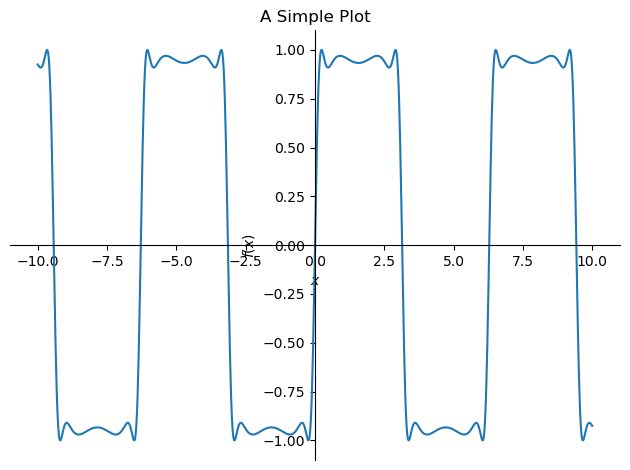

In [46]:
f = sin(2 * sin(2 * sin(2 * sin(x))))
p = plot(f, (x, -10, 10), show=False)
p.title = 'A Simple Plot'
p.show()

مشابه Matplotlib، SymPy یک رابط برای سفارشی‌سازی نمودار فراهم می‌کند

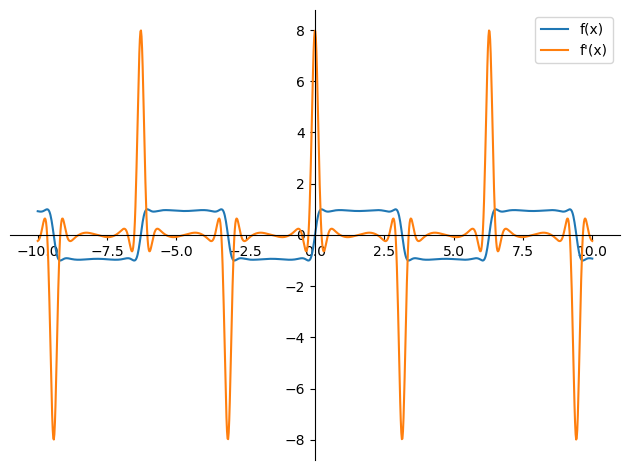

In [47]:
plot_f = plot(f, (x, -10, 10), 
              xlabel='', ylabel='', 
              legend = True, show = False)
plot_f[0].label = 'f(x)'
df = diff(f)
plot_df = plot(df, (x, -10, 10), 
            legend = True, show = False)
plot_df[0].label = 'f\'(x)'
plot_f.append(plot_df[0])
plot_f.show()

همچنین از ترسیم توابع ضمنی و تجسم نامساوی‌ها پشتیبانی می‌کند

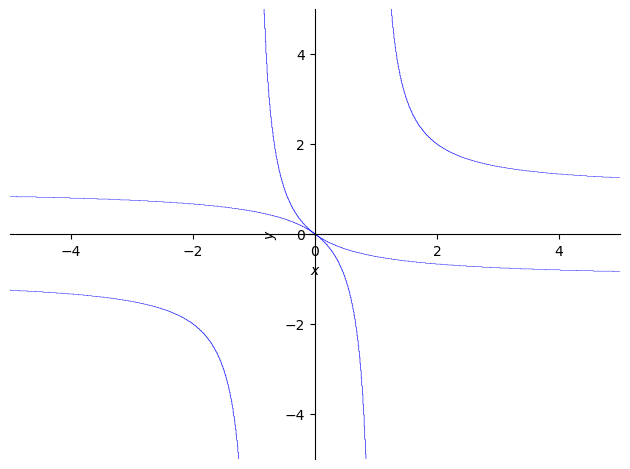

In [48]:
p = plot_implicit(Eq((1/x + 1/y)**2, 1))

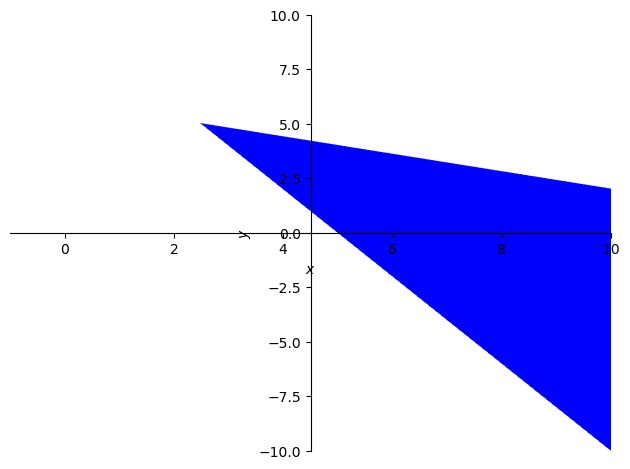

In [49]:
p = plot_implicit(And(2*x + 5*y <= 30, 4*x + 2*y >= 20),
                     (x, -1, 10), (y, -10, 10))

و تجسم‌سازی در فضای سه‌بعدی

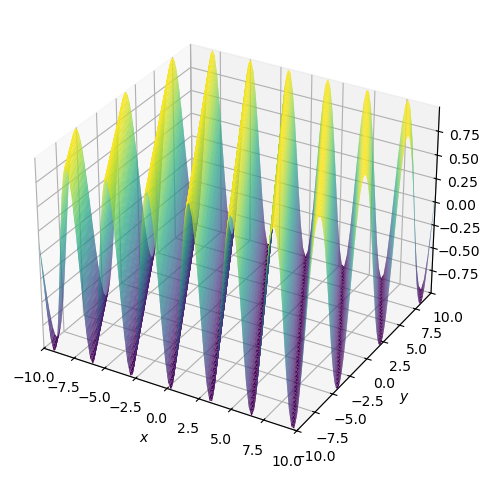

In [50]:
p = plot3d(cos(2*x + y), zlabel='')

## کاربرد: اقتصاد مبادله دو نفره

یک اقتصاد مبادله خالص با دو نفر ($a$ و $b$) و دو کالا که به صورت نسبت‌ها ($x$ و $y$) ثبت شده‌اند را تصور کنید.

آن‌ها می‌توانند کالاها را با یکدیگر مطابق با ترجیحات خود معامله کنند.

فرض کنید توابع مطلوبیت مصرف‌کنندگان به صورت زیر داده شده است

$$
u_a(x, y) = x^{\alpha} y^{1-\alpha}
$$

$$
u_b(x, y) = (1 - x)^{\beta} (1 - y)^{1-\beta}
$$

که در آن $\alpha, \beta \in (0, 1)$.

ابتدا نمادها و توابع مطلوبیت را تعریف می‌کنیم

In [51]:
# Define symbols and utility functions
x, y, α, β = symbols('x, y, α, β')
u_a = x**α * y**(1-α)
u_b = (1 - x)**β * (1 - y)**(1 - β)

In [52]:
u_a

 α  1 - α
x ⋅y     

In [53]:
u_b

       β        1 - β
(1 - x) ⋅(1 - y)     

ما به تخصیص بهینه پارتو کالاهای $x$ و $y$ علاقه‌مندیم.

توجه کنید که یک نقطه زمانی کارای پارتو است که تخصیص برای یک نفر با توجه به تخصیص برای شخص دیگر بهینه باشد.

از نظر مطلوبیت نهایی:

$$
\frac{\frac{\partial u_a}{\partial x}}{\frac{\partial u_a}{\partial y}} = \frac{\frac{\partial u_b}{\partial x}}{\frac{\partial u_b}{\partial y}}
$$

In [54]:
# A point is Pareto efficient when the allocation is optimal 
# for one person given the allocation for the other person

pareto = Eq(diff(u_a, x)/diff(u_a, y), 
            diff(u_b, x)/diff(u_b, y))
pareto

   1 - α  α - 1                       1 - β        β - 1 
y⋅y     ⋅y     ⋅α   -β⋅(1 - y)⋅(1 - y)     ⋅(1 - y)      
───────────────── = ─────────────────────────────────────
    x⋅(1 - α)                  (1 - x)⋅(β - 1)           

In [55]:
# Solve the equation
sol = solve(pareto, y)[0]
sol

    x⋅β⋅(α - 1)    
───────────────────
x⋅α - x⋅β + α⋅β - α

بیایید تخصیص‌های بهینه پارتو اقتصاد (منحنی‌های قرارداد) را با $\alpha = \beta = 0.5$ با استفاده از SymPy محاسبه کنیم

In [56]:
# Substitute α = 0.5 and β = 0.5
sol.subs({α: 0.5, β: 0.5})

1.0⋅x

می‌توانیم از این نتیجه برای تجسم منحنی‌های قرارداد بیشتر تحت پارامترهای مختلف استفاده کنیم

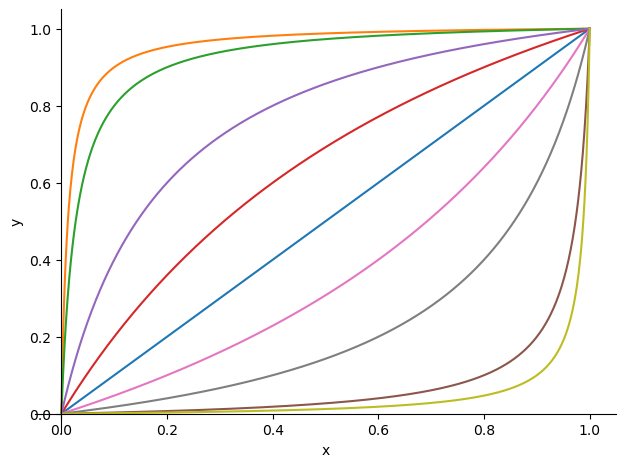

In [57]:
# Plot a range of αs and βs
params = [{α: 0.5, β: 0.5}, 
          {α: 0.1, β: 0.9},
          {α: 0.1, β: 0.8},
          {α: 0.8, β: 0.9},
          {α: 0.4, β: 0.8}, 
          {α: 0.8, β: 0.1},
          {α: 0.9, β: 0.8},
          {α: 0.8, β: 0.4},
          {α: 0.9, β: 0.1}]

p = plot(xlabel='x', ylabel='y', show=False)

for param in params:
    p_add = plot(sol.subs(param), (x, 0, 1), 
                 show=False)
    p.append(p_add[0])
p.show()

شما را دعوت می‌کنیم با پارامترها بازی کنید و ببینید منحنی‌های قرارداد چگونه تغییر می‌کنند و در مورد دو سؤال زیر فکر کنید:

- آیا می‌توانید راهی برای ترسیم همان نمودار با استفاده از `numpy` به نظر بیاورید؟
- پیاده‌سازی `numpy` چقدر دشوار خواهد بود؟

## تمرینات

```{exercise}
:label: sympy_ex1

قاعده لوپیتال بیان می‌کند که برای دو تابع $f(x)$ و $g(x)$، اگر $\lim_{x \to a} f(x) = \lim_{x \to a} g(x) = 0$ یا $\pm \infty$، آنگاه

$$
\lim_{x \to a} \frac{f(x)}{g(x)} = \lim_{x \to a} \frac{f'(x)}{g'(x)}
$$

از SymPy برای تأیید قاعده لوپیتال برای توابع زیر استفاده کنید

$$
f(x) = \frac{y^x - 1}{x}
$$

وقتی $x$ به $0$ نزدیک می‌شود
```

```{solution-start} sympy_ex1
:class: dropdown
```

بیایید ابتدا تابع را تعریف کنیم

In [58]:
f_upper = y**x - 1
f_lower = x
f = f_upper/f_lower
f

 x    
y  - 1
──────
  x   

Sympy به اندازه کافی هوشمند است که این حد را حل کند

In [59]:
lim = limit(f, x, 0)
lim

log(y)

نتیجه پیشنهادی قاعده لوپیتال را مقایسه می‌کنیم

In [60]:
lim = limit(diff(f_upper, x)/
            diff(f_lower, x), x, 0)
lim

log(y)

```{solution-end}
```

```{exercise}
:label: sympy_ex2

[برآورد حداکثر درستنمایی (MLE)](https://python.quantecon.org/mle.html) روشی برای برآورد پارامترهای یک مدل آماری است.

این روش معمولاً شامل حداکثرسازی یک تابع لگاریتم درستنمایی و حل مشتق مرتبه اول است.

توزیع دوجمله‌ای به صورت زیر داده می‌شود

$$
f(x; n, θ) = \frac{n!}{x!(n-x)!}θ^x(1-θ)^{n-x}
$$

که در آن $n$ تعداد آزمایش‌ها و $x$ تعداد موفقیت‌ها است.

فرض کنید ما یک سری نتایج دودویی با $x$ موفقیت از $n$ آزمایش مشاهده کردیم.

MLE $θ$ را با استفاده از SymPy محاسبه کنید
```

```{solution-start} sympy_ex2
:class: dropdown
```

ابتدا، توزیع دوجمله‌ای را تعریف می‌کنیم

In [61]:
n, x, θ = symbols('n x θ')

binomial_factor = (factorial(n)) / (factorial(x)*factorial(n-x))
binomial_factor

    n!     
───────────
x!⋅(n - x)!

In [62]:
bino_dist = binomial_factor * ((θ**x)*(1-θ)**(n-x))
bino_dist

 x        n - x   
θ ⋅(1 - θ)     ⋅n!
──────────────────
   x!⋅(n - x)!    

اکنون تابع لگاریتم درستنمایی را محاسبه کرده و برای نتیجه حل می‌کنیم

In [63]:
log_bino_dist = log(bino_dist)

In [64]:
log_bino_diff = simplify(diff(log_bino_dist, θ))
log_bino_diff

 -x - 1        -n + x - 1 ⎛   x        n - x + 1    x + 1        n - x        ⎞
θ      ⋅(1 - θ)          ⋅⎝x⋅θ ⋅(1 - θ)          - θ     ⋅(1 - θ)     ⋅(n - x)⎠

In [65]:
solve(Eq(log_bino_diff, 0), θ)[0]

x
─
n

```{solution-end}
```